# Sparseness Optimized Feature Importance for Time Series Classification

SOFI is a model-agnostic post hoc explainer. An explanation is a ranking of time series segments, and its quality is the degradation score, namely the integral between two degradation curves. The MoRF curve marginalizes the most relevant segments first and should collapse immediately, while the LeRF curve marginalizes the least relevant ones first and should stay flat for as long as possible. Maximizing the gap rewards sparsity and correctness at once, and both curves are read as probabilities of the explained class.

The notebook has two parts, and they answer two different questions.

| Part | Question | Covered |
| --- | --- | --- |
| 1. Explaining a decision | how is the explainer set up, and what does it draw | four frameworks, the report, every figure of an explanation, expert breakpoints |
| 2. Running experiments | how are many runs compared against one another | the `Experiment` class, its grid figures, segmentations, operators, competing rankings and batches |

The first part is the ordinary use of the package, one instance at a time. The second part serves a study and is never needed to explain a single decision.

The well-known Cylinder Bell Funnel dataset is used throughout. It is a three class benchmark whose shapes are visually recognizable, so an explanation can be verified against the series itself, and it is distributed with the package, so no download is required.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

import sofits
from sofits import Experiment, SOFIExplainer, load_dataset, manual_segmentation

RANDOM_STATE = 42
N_SEGMENTS = 12

print("sofits", sofits.__version__)

sofits 1.0.0


## Part 1. Explaining a decision

### The data and the instance under study

A single test instance carries the whole notebook, so that every configuration is compared on identical ground. It belongs to the funnel class, whose spike provides a localized feature on which a classifier can rely. In an application this instance is the one the expert brings, and the package explains the decision made on it.

CBF, 3 classes, 30 train and 900 test instances, 1 channel(s) of 128 points [local]
true class of instance 5 is 3


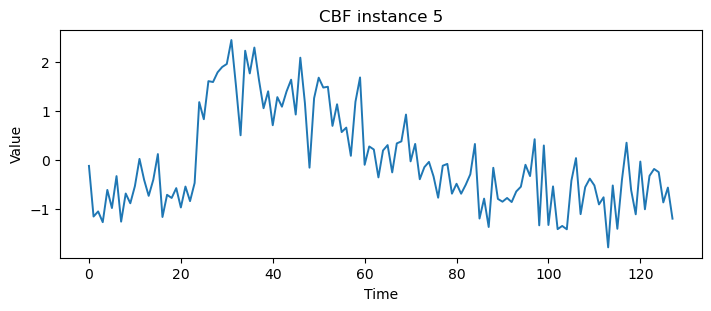

In [2]:
cbf = load_dataset("CBF")
print(cbf.summary())

INSTANCE = 5
instance = cbf.X_test[INSTANCE]
print("true class of instance", INSTANCE, "is", cbf.y_test[INSTANCE])

figure, ax = plt.subplots(figsize=(7, 3), layout="constrained")
ax.plot(instance[0], color="tab:blue", linewidth=1.4)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title(f"CBF instance {INSTANCE}")
plt.show()

### Configuring the explainer

SOFI queries a classifier for class probabilities and for nothing else, so the architecture is irrelevant to the method. What differs between frameworks is the calling convention, and two conventions are resolved on a probe batch when the explainer is built. The output convention states whether the raw output already lies on the probability simplex, and a softmax is applied only when it does not. The channel layout states whether the model expects the channel axis before the time axis, as PyTorch does, or after it, as Keras does. Both can also be declared, which the PyTorch block below does. These settings are illustrated below.

#### A scikit-learn estimator

Anything exposing `predict_proba` is recognized, which covers scikit-learn together with the `aeon` and `sktime` wrappers.

In [3]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

y_train, y_test = cbf.codes(cbf.y_train), cbf.codes(cbf.y_test)
flat_train = cbf.X_train.reshape(len(cbf.X_train), -1)
flat_test = cbf.X_test.reshape(len(cbf.X_test), -1)

sklearn_model = make_pipeline(
    StandardScaler(), MLPClassifier((256, 128), max_iter=2000, random_state=RANDOM_STATE)
).fit(flat_train, y_train)

print("Test accuracy:", round(sklearn_model.score(flat_test, y_test), 3))

Test accuracy: 0.906


[sofits] backend sklearn, 3 classes, channels_first=True, output=proba
Predicted class: 3


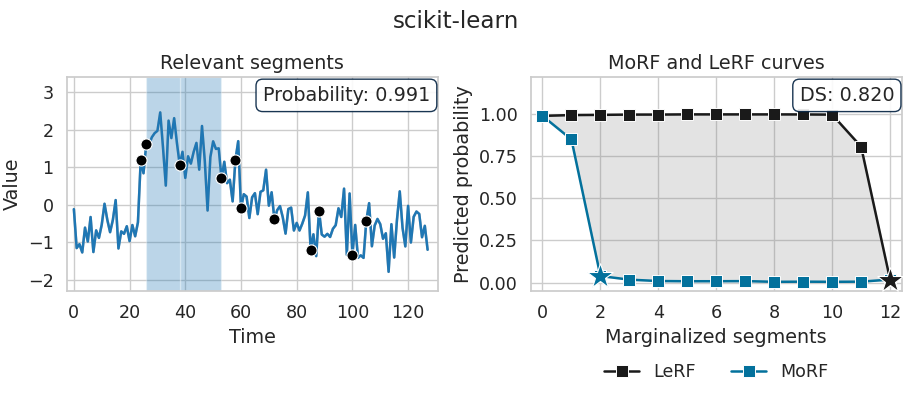

In [4]:
sklearn_explainer = SOFIExplainer(
    sklearn_model,
    cbf.X_train,
    cbf.y_train,
    classes=cbf.classes,
    segmentation="binseg",
    segmentation_params={"n_segments": N_SEGMENTS},
    marginalization="mean",
    random_state=RANDOM_STATE,
)
sklearn_explanation = sklearn_explainer.explain(instance)
print("Predicted class:", sklearn_explanation.class_name)

sklearn_explanation.plot_explanation(title="scikit-learn", figsize=(9,4))
plt.show()

#### A PyTorch module

A fully convolutional network, the usual baseline of the field. Its `forward` returns raw scores rather than probabilities and it expects the channel axis first. Both conventions would be detected on their own, and they are stated here to show how a user declares them when a probe would be ambiguous.

In [5]:
import torch
import torch.nn as nn

class FCN(nn.Module):
    """Fully convolutional classifier for time series."""

    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv1d(n_channels, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
        )
        self.head = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.head(self.body(x))


torch.manual_seed(RANDOM_STATE)
torch_model = FCN(cbf.n_channels, cbf.n_classes)
optimizer = torch.optim.AdamW(torch_model.parameters(), 1e-2)
inputs, targets = torch.tensor(cbf.X_train, dtype=torch.float32), torch.tensor(y_train)

torch_model.train()
for epoch in range(300):
    optimizer.zero_grad()
    nn.CrossEntropyLoss()(torch_model(inputs), targets).backward()
    optimizer.step()
torch_model.eval()

with torch.no_grad():
    scores = torch_model(torch.tensor(cbf.X_test, dtype=torch.float32))
print("Test accuracy:", round(float((scores.argmax(1).numpy() == y_test).mean()), 3))

Test accuracy: 0.99


[sofits] backend torch, 3 classes, channels_first=True, output=logits
Predicted class: 3


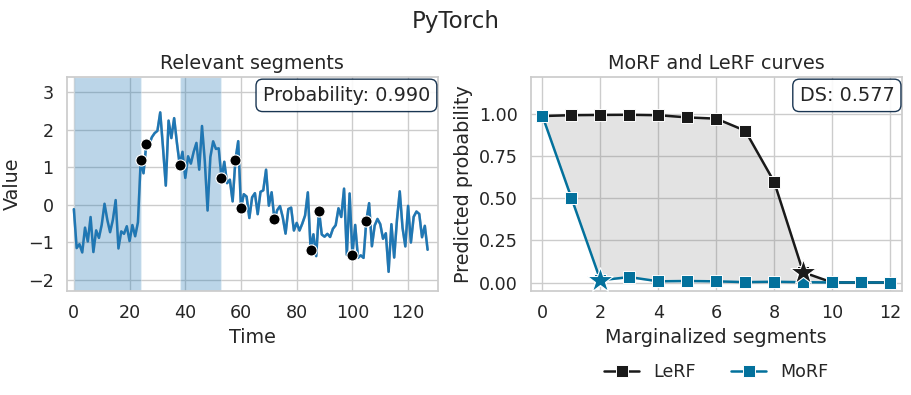

In [6]:
torch_explainer = SOFIExplainer(
    torch_model,
    cbf.X_train,
    cbf.y_train,
    classes=cbf.classes,
    output="logits",            # the network returns raw scores
    channels_first=True,        # and expects the channel axis first
    segmentation="binseg",
    segmentation_params={"n_segments": N_SEGMENTS},
    marginalization="mean",
    random_state=RANDOM_STATE,
)
torch_explanation = torch_explainer.explain(instance)
print("Predicted class:", torch_explanation.class_name)

torch_explanation.plot_explanation(title="PyTorch", figsize=(9,4))
plt.show()

#### A Keras model

Keras places the time axis before the channel axis and its final layer already applies a softmax, so both conventions differ from the PyTorch.

In [7]:
# Keras 3 needs a backend, and PyTorch is already a dependency of this notebook
os.environ.setdefault("KERAS_BACKEND", "torch")
import keras

keras.utils.set_random_seed(RANDOM_STATE)
keras_model = keras.Sequential([
    keras.layers.Input((cbf.n_timestamps, cbf.n_channels)),
    keras.layers.Conv1D(64, 7, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv1D(64, 5, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(cbf.n_classes, activation="softmax"),
])
keras_model.compile(keras.optimizers.Adam(1e-2), "sparse_categorical_crossentropy")

# Keras expects the time axis first, which is why the arrays are transposed here
keras_model.fit(np.transpose(cbf.X_train, (0, 2, 1)), y_train, epochs=600, batch_size=16, verbose=0)
keras_scores = keras_model.predict(np.transpose(cbf.X_test, (0, 2, 1)), verbose=0)
print("Test accuracy:", round(float((keras_scores.argmax(1) == y_test).mean()), 3))

Test accuracy: 0.994


[sofits] backend keras, 3 classes, channels_first=False, output=proba
Predicted class: 3


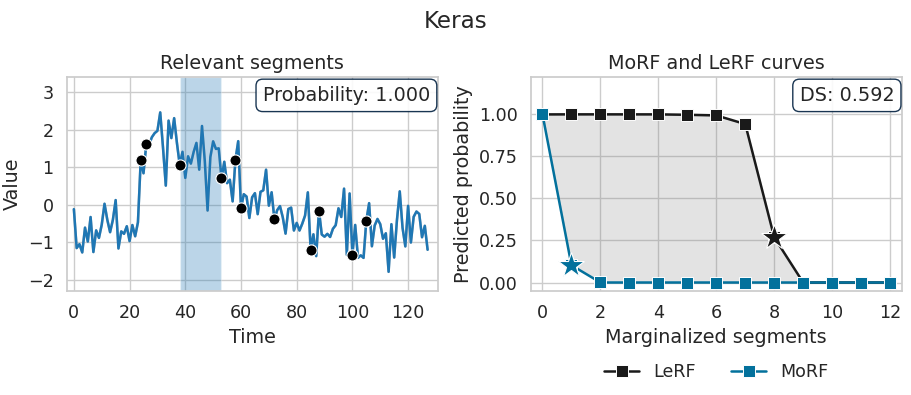

In [8]:
keras_explainer = SOFIExplainer(
    keras_model,
    cbf.X_train,
    cbf.y_train,
    classes=cbf.classes,
    segmentation="binseg",
    segmentation_params={"n_segments": N_SEGMENTS},
    marginalization="mean",
    random_state=RANDOM_STATE,
)
keras_explanation = keras_explainer.explain(instance)
print("Predicted class:", keras_explanation.class_name)

keras_explanation.plot_explanation(title="Keras", figsize=(9,4))
plt.show()

#### A tsai learner
An InceptionTime learner, the architecture used in the paper. The learner is recognized through `get_X_preds`, from which the probabilities are read.

In [11]:
# recent versions of fastcore no longer re-export inspect, which some releases of
# fastai still expect. The two lines restore the name before tsai is imported
import inspect

import fastcore.basics
fastcore.basics.inspect = inspect

from tsai.basics import TSCategorize, TSClassifier, TSStandardize

X_all = np.concatenate([cbf.X_train, cbf.X_test]).astype("float32")
y_all = np.concatenate([y_train, y_test]).astype("int64")
train_positions = list(range(len(cbf.X_train)))
test_positions = list(range(len(cbf.X_train), len(X_all)))

tsai_model = TSClassifier(
    X_all, y_all, splits=(train_positions, test_positions), arch="InceptionTime",
    tfms=[None, TSCategorize()], batch_tfms=[TSStandardize()], metrics=None, bs=32,
)
with tsai_model.no_bar(), tsai_model.no_logging():
    tsai_model.fit_one_cycle(25, 1e-3)
    tsai_scores = np.asarray(tsai_model.get_X_preds(cbf.X_test.astype("float32"))[0])
print("Test accuracy:", round(float((tsai_scores.argmax(1) == y_test).mean()), 3))

Test accuracy: 0.997


[sofits] backend tsai, 3 classes, channels_first=True, output=proba
Predicted class: 3


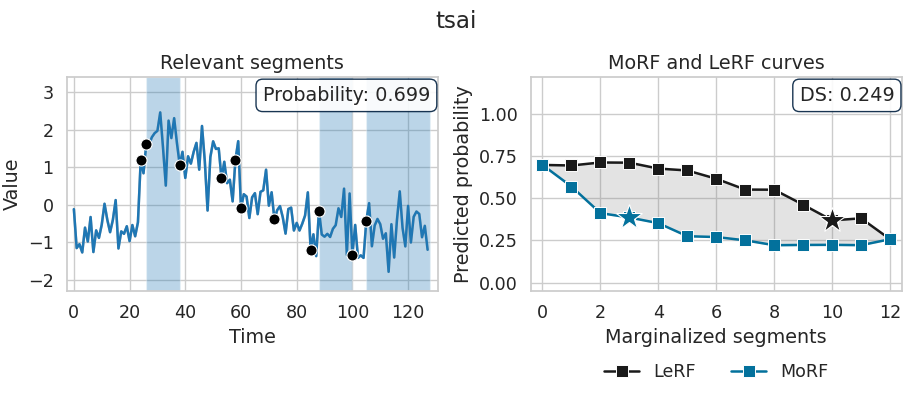

In [12]:
tsai_explainer = SOFIExplainer(
    tsai_model,
    cbf.X_train,
    cbf.y_train,
    classes=cbf.classes,
    segmentation="binseg",
    segmentation_params={"n_segments": N_SEGMENTS},
    marginalization="mean",
    random_state=RANDOM_STATE,
)
tsai_explanation = tsai_explainer.explain(instance)
print("Predicted class:", tsai_explanation.class_name)

tsai_explanation.plot_explanation(title="tsai", figsize=(9,4))
plt.show()

The four models assign the same class to this instance, yet they resort to different segments in order to do so. The left panel of each figure marks the smallest set of segments whose cumulative marginalization changes the decision, and those sets differ from one framework to the next even though the decision itself does not. A prediction and an explanation are separate objects, and agreement on the first implies nothing about the second. The right panel carries two stars. The one on the MoRF curve marks the step at which the predicted class first changes, and the one on the LeRF curve marks the same event when the ranking is walked backwards. The separation between curves measures how much earlier the ranking induces the change of class than its reverse, and a LeRF curve without a star says the class never changed.

### Exploring the instance being explained

`inspect` reports the statistics of the series, the confidence of the model with its runner up class, and the geometry of the segmentation. It closes with a separation index that compares the variance left inside the segments with the total variance, so a value near one says the breakpoints captured almost every level change. Warnings appear when the decision sits near a class boundary, when the instance is misclassified, or when the segments barely separate the series, since none of those yields a ranking worth reading.

Instance under study
  shape          1 channel(s) of 128 time points
  range          [-1.788, 2.456], span 4.243
  center         mean 0.000, median -0.273, deviation 0.996
  roughness      mean absolute step 0.5678, 94 turning points
------------------------------------------------------------------------------
  prediction     class 3 at probability 0.9897, correct
  runner up      class 2 at 0.0100, margin 0.9798
  uncertainty    entropy 0.0585, normalized 0.053
------------------------------------------------------------------------------
  segmentation   binseg, 12 segments covering 100% of the series
  lengths        shortest 2, longest 24, mean 10.7
  separation     0.826 of the variance is explained by the segment means


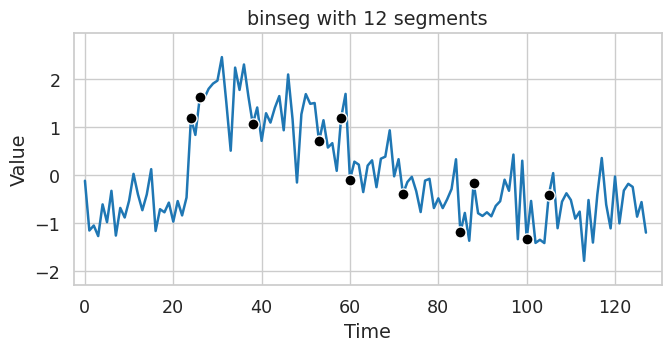

In [13]:
explainer = torch_explainer
explanation = torch_explanation

facts = explainer.inspect(instance, true_label=cbf.y_test[INSTANCE])
plt.show()

### Reading the result

A complete report of the run is obtained with a single call. It names the operator, the reading that follows from it, and the entire ranking. The tabular view carries one row per marginalization step, with the probability that survives it and the drop attributable to it.

In [14]:
print(explanation.summary())

SOFI explanation
  explained class           3
  segmentation              binseg, 12 segments
  marginalization           constant mean at 0.0000
  reading                   Segments are ranked by how much the prediction relies on them.
  degradation score         0.5767
  area under MoRF           0.0896
  area under LeRF           0.6664
  unperturbed probability   0.9897
  class change              after 2 of 12 segments, rate 0.167, against step 9 under LeRF
  noise region              none detected
  modularity gap            0.2900, segment effects are conditional
  search                    200 iterations, 0 restarts, 150 evaluations, 302 model queries
  ranking                   1. s3, 2. s0, 3. s2, 4. s11, 5. s9, 6. s7, 7. s6, 8. s5, 9. s4, 10. s8, 11. s1, 12. s10


In [15]:
explanation.to_frame().round(4)

,step,segment,channel,start,end,probability,drop,importance,noise
0,1,s3,0,38,53,0.5024,0.4874,0.1538,False
1,2,s0,0,0,24,0.0135,0.4889,0.1410,False
2,3,s2,0,26,38,0.0323,-0.0189,0.1282,False
3,4,s11,0,105,128,0.0071,0.0253,0.1154,False
4,5,s9,0,88,100,0.0090,-0.0020,0.1026,False
5,6,s7,0,72,85,0.0069,0.0021,0.0897,False
6,7,s6,0,60,72,0.0023,0.0045,0.0769,False
7,8,s5,0,58,60,0.0047,-0.0023,0.0641,False
8,9,s4,0,53,58,0.0018,0.0029,0.0513,False
9,10,s8,0,85,88,0.0004,0.0014,0.0385,False


### Every figure an explanation draws

An explanation carries the instance, the segments, both curves and the states the series passed through, so it draws its own figures without further arguments. Every method accepts the settings of the figure it produces, such as the thickness of the lines, the colors, the size of the panels or the titles, and every one of them writes the figure to disk through `save_path`. A path without an extension receives `.pdf` for a static figure and `.gif` for the animation.

| Method | Figure |
| --- | --- |
| `plot_segmentation` | The series with the breakpoints that divide it |
| `plot_degradation_curves` | The MoRF and LeRF curves and the area between them |
| `plot_explanation` | Two panels, the relevant segments beside the curves |
| `plot_marginalization` | Snapshots of the series along the cumulative marginalization |
| `plot_animation` | The two passes as an animated GIF, shown in the cell below |


Below, we will illustrate how to call these functions. For simplicity, we will use `plot_marginalization` and `plot_animation`.

Segments are marginalized cumulatively, so the effect of a segment depends on what was already removed and no independent score describes it. The figure below reports the process rather than summarizing it. The untouched series is in gray, the series after the first few segments of the ranking have been removed is in color, the region already marginalized is shaded behind them, and the surviving probability heads each panel, so the collapse of the MoRF curve can be read off the series itself.

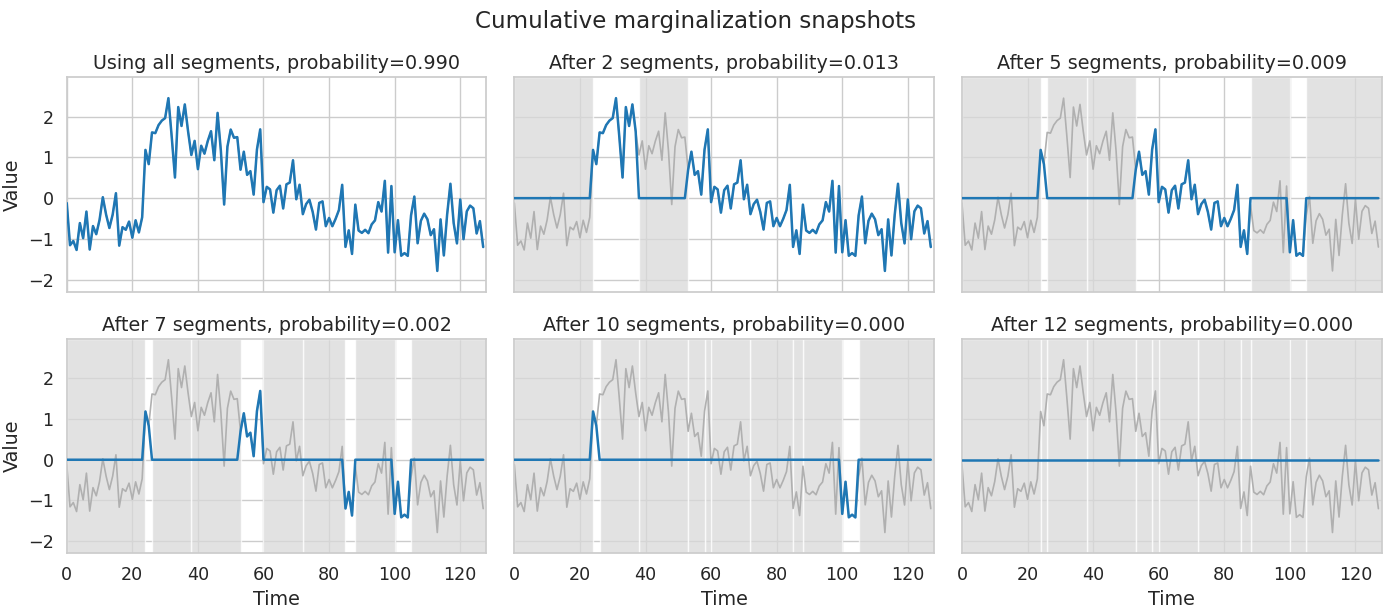

In [16]:
explanation.plot_marginalization(ncols=3, panel_size=(4.6, 3.1))
plt.show()

The animation follows the same process one frame at a time. The LeRF pass runs first, marginalizing the least relevant segment and working towards the most relevant one, then the panel is cleared and the MoRF pass runs in the opposite direction. Once both curves are complete, the area between them is shaded and the series is redrawn carrying the segments that constitute the explanation, which is the figure `plot_explanation` produces.

The cell displays the animation on its own. Passing `save_path` writes the same GIF to disk, and the object returned can be written afterwards with `save`.

Rendering frames:   0%|          | 0/28 [00:00<?, ?it/s]

Animation(28 frames, 430 KiB, held in memory)
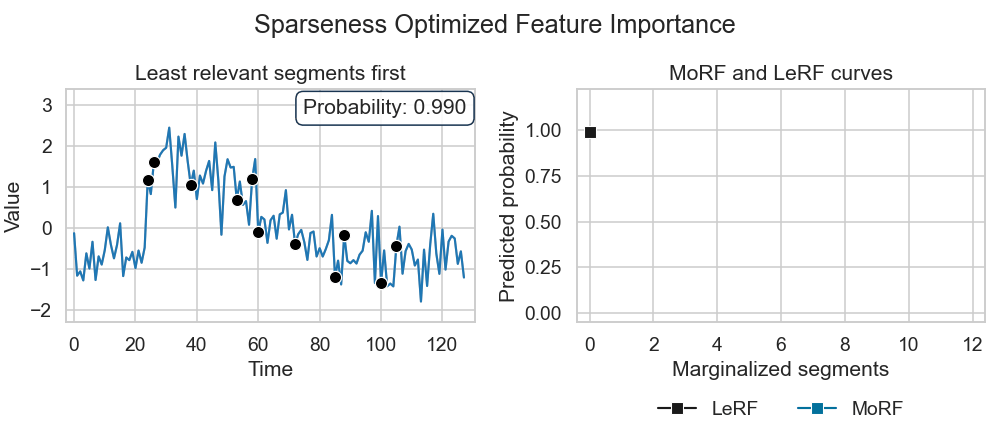

In [17]:
animation = explanation.plot_animation(figsize=(9,4))
animation

In [18]:
animation.save("figures/marginalization.gif")

'figures\\marginalization.gif'

### Segments supplied by an expert

Segments are the unit of interpretation and they belong to the user. A cardiologist reads an electrocardiogram in terms of waves and intervals rather than time points, so an explanation phrased in those terms is meaningful while one phrased in time points is not. Any list of breakpoints is accepted, which is how domain knowledge enters the procedure. The positions below are invented for the illustration, since this benchmark carries no annotation, and they show the mechanism rather than any real structure.

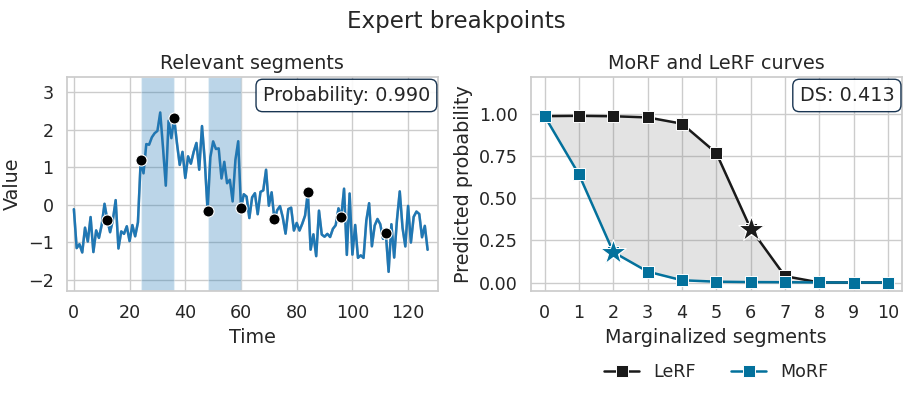

ranking: s2, s4, s1, s9, s3, s7, s5, s6, s8, s0


In [19]:
expert = manual_segmentation([12, 24, 36, 48, 60, 72, 84, 96, 112], cbf.n_timestamps)
expert_explanation = explainer.explain(instance, segmentation=expert)

expert_explanation.plot_explanation(title="Expert breakpoints", figsize=(9,4))
plt.show()

print("ranking:", ", ".join(expert_explanation.ranking))

## Part 2. Running experiments

Everything above concerns one decision. A study asks a different question, namely how many runs compare against one another, and `Experiment` gathers what that question needs. It is bound to an explainer, whose segmentation and operator define the protocol every comparison runs under. Each comparison returns a mapping from a heading onto an explanation, which the three grid figures and `summarize` accept directly.

| Grid | What it draws |
| --- | --- |
| `plot_explanation_grid` | The relevant segments of every run, the left panel of `plot_explanation` |
| `plot_degradation_grid` | The MoRF and LeRF curves of every run, the right panel of `plot_explanation` |
| `plot_segmentation_grid` | One instance under several partitions, with no segment singled out |

In [20]:
study = Experiment(explainer, random_state=RANDOM_STATE)
study

Experiment(explainer=SOFIExplainer(segmentation='binseg', marginalization='mean', backend=torch))

### Choosing the instances of a study

`select_reliable_instances` keeps the instances the model gets right. The premise of the method is that the response deteriorates as segments are marginalized, which only holds for instances the model handles well, so a study that pools results over a whole test set has to state its criterion and this one is the usual choice.

This function serves experiments only. In an application the instance to explain is the one the expert brings, and no filter is applied to it.

In [21]:
reliable, mask = study.select_reliable_instances(cbf.X_test, cbf.y_test, return_mask=True)
print("retained", len(reliable), "of", len(cbf.X_test), "test instances")

retained 891 of 900 test instances


### Comparing segmentation procedures

Segments decide what an explanation can say, so the partition is the first thing a study varies. Six procedures are compared below on the same instance, with the breakpoints marked on the series itself. PELT is driven by a penalty rather than by a count, so it decides for itself how many breakpoints the series deserves, while the others take the count as given.

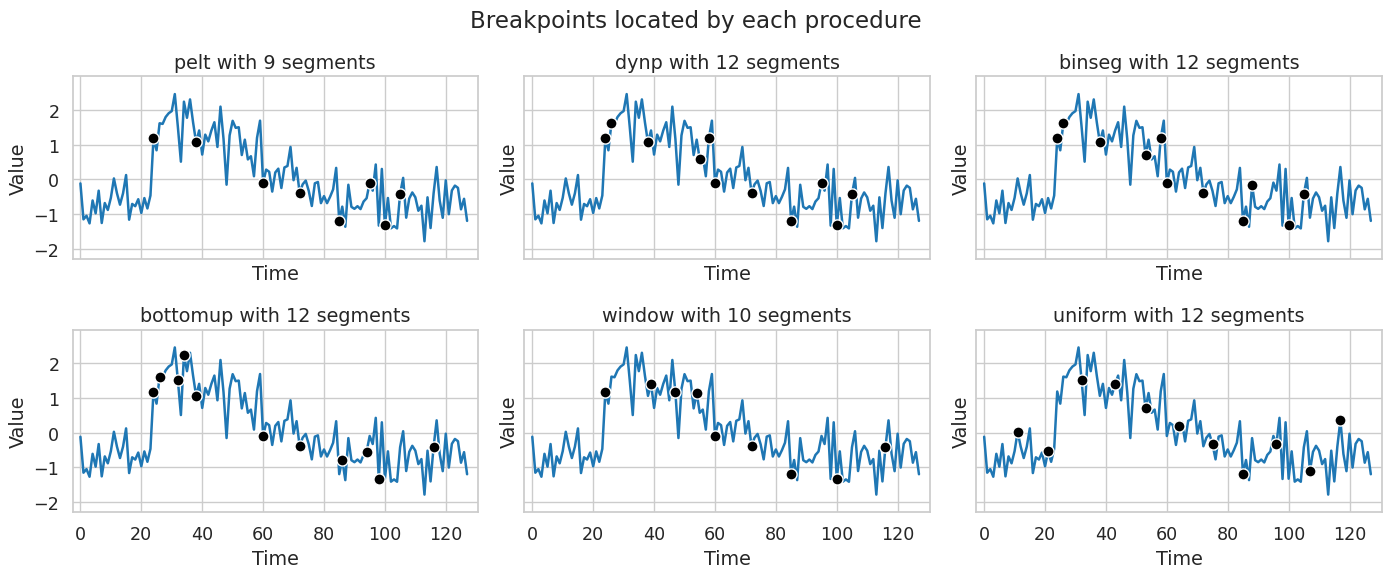

In [22]:
segmentations = {
    "pelt": explainer.segment(instance, method="pelt", penalty=0.8, min_size=4),
    "dynp": explainer.segment(instance, method="dynp", n_segments=N_SEGMENTS),
    "binseg": explainer.segment(instance, method="binseg", n_segments=N_SEGMENTS),
    "bottomup": explainer.segment(instance, method="bottomup", n_segments=N_SEGMENTS),
    "window": explainer.segment(instance, method="window", n_segments=N_SEGMENTS, width=10),
    "uniform": explainer.segment(instance, segmentation="uniform", n_segments=N_SEGMENTS),
}

study.plot_segmentation_grid(
    instance, segmentations, ncols=3, title="Breakpoints located by each procedure",
)
plt.show()

Each vocabulary is then submitted to the same search. The first grid answers which parts of the series each partition held responsible for the decision, and the second answers how fast each of them degrades the response. A steeper MoRF curve says the procedure isolated the evidence in fewer segments.

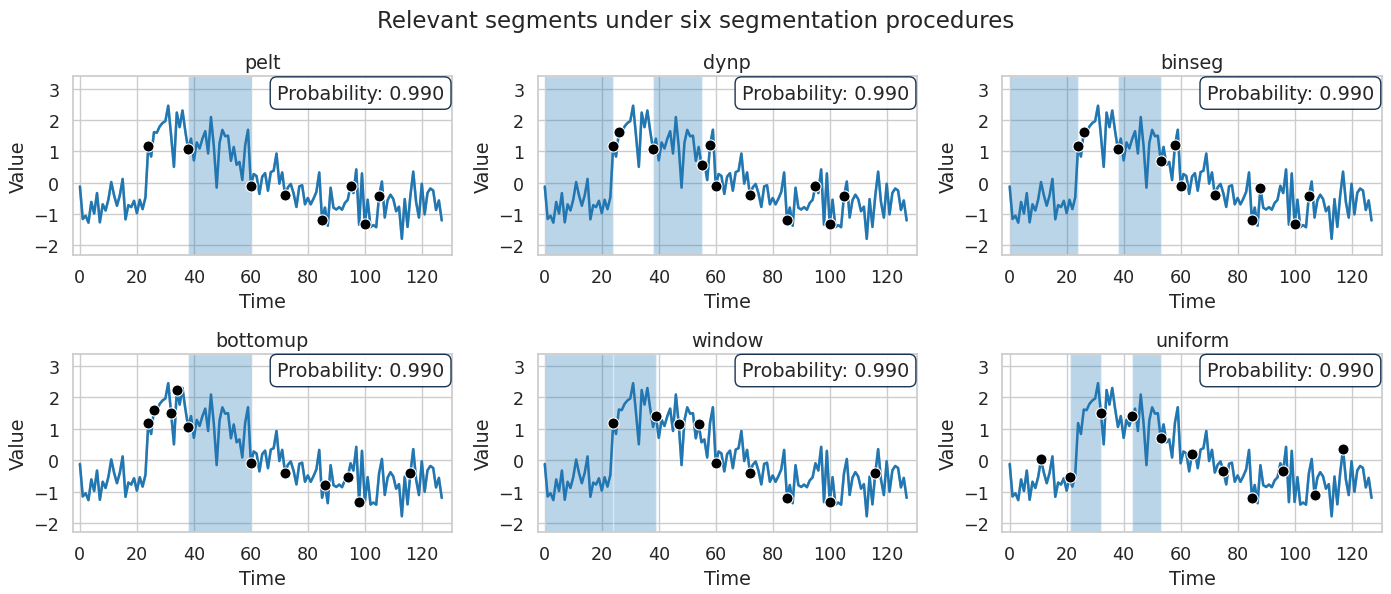

In [23]:
by_procedure = study.compare_segmentations(instance, segmentations)

study.plot_explanation_grid(
    by_procedure, ncols=3, panel_size=(4.6, 3.0),
    title="Relevant segments under six segmentation procedures",
)
plt.show()

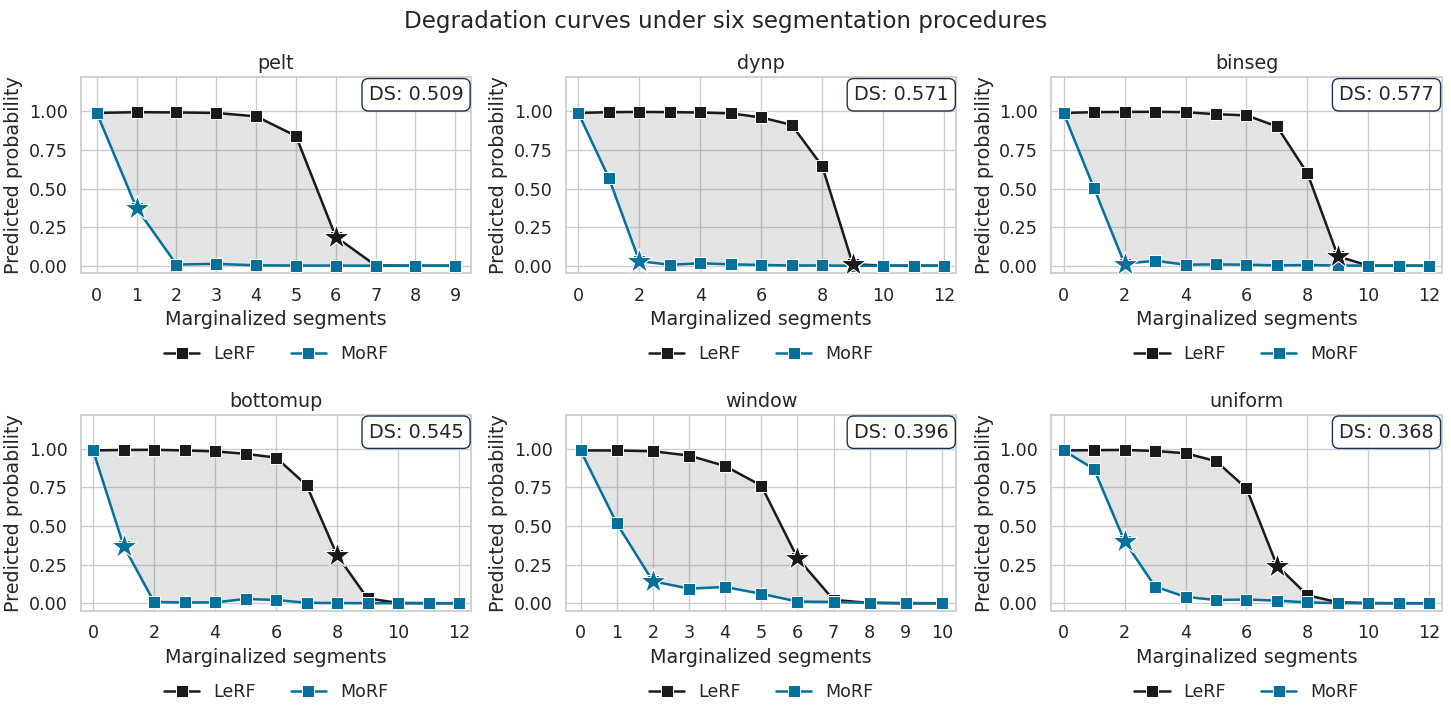

In [24]:
study.plot_degradation_grid(
    by_procedure, ncols=3, panel_size=(4.8, 3.6),
    title="Degradation curves under six segmentation procedures",
)
plt.show()

In [25]:
study.summarize(by_procedure).round(4)

,run,predicted,confidence,ds,sparsity_rate,n_segments,model_queries,runtime,top_3
0,pelt,3,0.9897,0.5087,0.1111,9,176,0.5448,"s2, s0, s1"
1,dynp,3,0.9897,0.5712,0.1667,12,320,1.1845,"s0, s3, s11"
2,binseg,3,0.9897,0.5767,0.1667,12,302,1.3414,"s3, s0, s2"
3,bottomup,3,0.9897,0.5448,0.0833,12,318,1.4343,"s5, s0, s10"
4,window,3,0.9897,0.3955,0.2000,10,254,0.8542,"s1, s0, s7"
5,uniform,3,0.9897,0.3684,0.1667,12,212,0.6023,"s4, s2, s3"


### Comparing marginalization operators

Marginalizing a tabular feature is easy, since one statistic of the training column carries no instance level information. A time series segment is harder, because a flat constant is itself a shape and a model may read it as evidence for some class, which leaves the marginalized series informative and the curve misleading.

Operators fall into two families that carry different readings. Class agnostic operators erase the content of a segment without steering the prediction anywhere, so their rankings say which segments the prediction relies on, which is the question the method was designed for. Class directed operators choose the substitution so that the response falls as fast as possible, so their rankings say which segments move the model away from its current class fastest, which is a counterfactual question. Every explanation states which family produced it, and `sofits.CLASS_AGNOSTIC` and `sofits.CLASS_DIRECTED` list the fourteen names.

A steep MoRF curve against a flat LeRF curve is what a sound substitution looks like. Curves that stay close together say the operator failed to remove anything the model cared about.

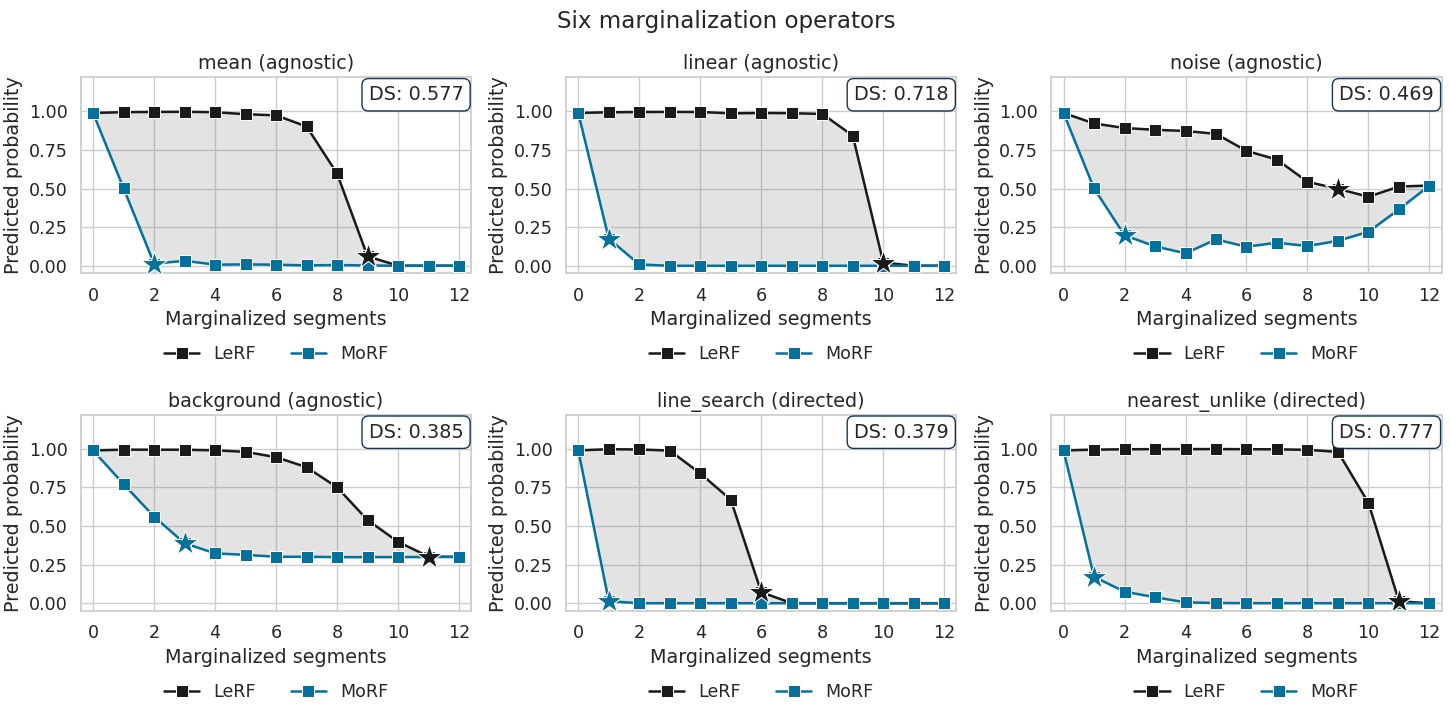

In [26]:
segmentation = segmentations["binseg"]
operators = ["mean", "linear", "noise", "background", "line_search", "nearest_unlike"]

by_operator = study.compare_marginalizations(
    instance, operators, segmentation=segmentation
)

study.plot_degradation_grid(
    {
        f"{name} ({'directed' if run.class_directed else 'agnostic'})": run
        for name, run in by_operator.items()
    },
    ncols=3, panel_size=(4.8, 3.6), title="Six marginalization operators",
)
plt.show()

Two controls apply to every operator. The number of replicas averages the response over several substitutions, which approximates an expectation rather than the output at one arbitrary point, and the taper blends the substituted values into their neighbors, which removes the step discontinuity a flat constant introduces at a breakpoint. Convolutional models react strongly to sharp edges, so part of a measured degradation can be a boundary artifact rather than lost evidence.

A marginalization operator given as a dictionary carries its own arguments, which allows for easy customization. Since no single setting is appropriate for every problem, `"auto"` treats the choice as a hyperparameter and resolves it for each instance, running the search once per candidate and retaining the highest degradation score. The candidates are the cheap class agnostic operators, so the reading of the ranking never changes without being asked for.

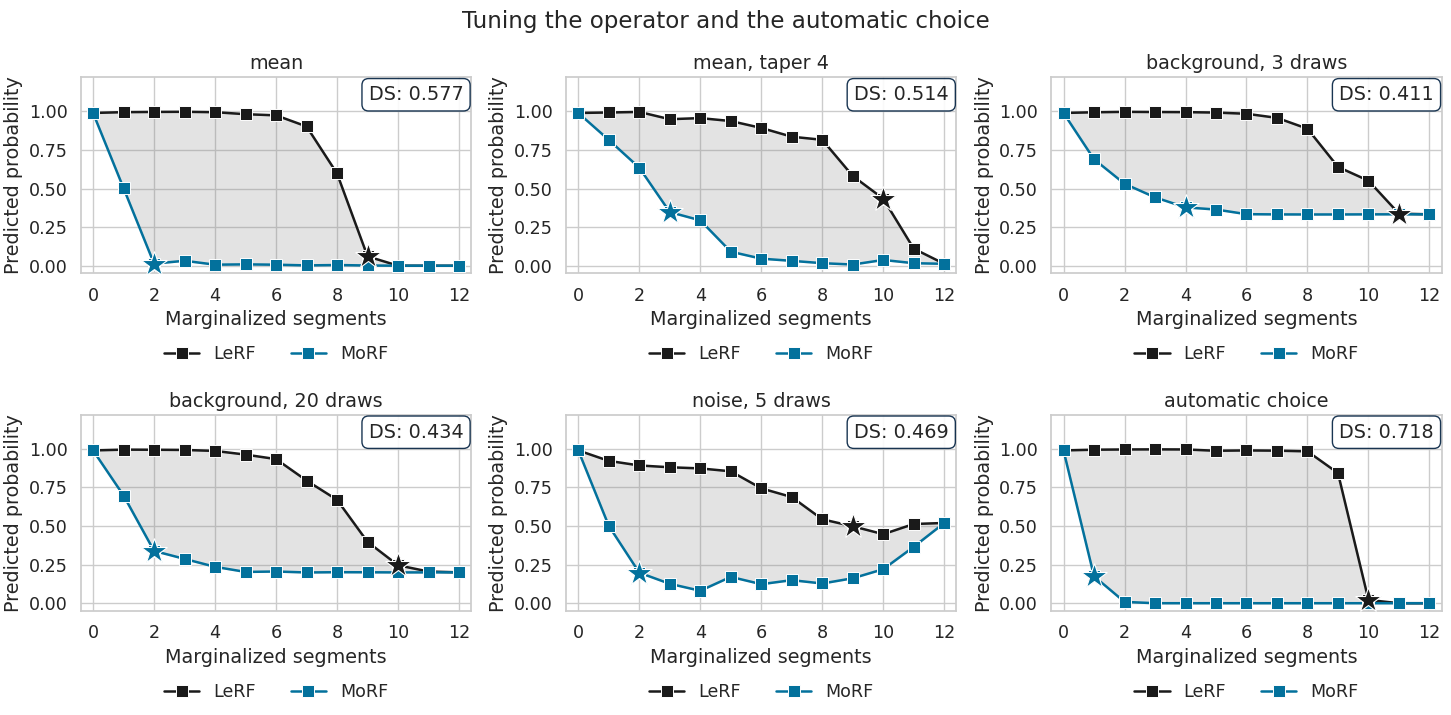

operator selected automatically: linear interpolation between the segment endpoints


In [27]:
variants = {
    "mean": "mean",
    "mean, taper 4": {"marginalization": "mean", "taper": 4},
    "background, 3 draws": {"marginalization": "background", "n_replicas": 3},
    "background, 20 draws": {"marginalization": "background", "n_replicas": 20},
    "noise, 5 draws": {"marginalization": "noise", "n_replicas": 5},
    "automatic choice": "auto",
}

by_variant = study.compare_marginalizations(instance, variants, segmentation=segmentation)

study.plot_degradation_grid(
    by_variant, ncols=3, panel_size=(4.8, 3.6),
    title="Tuning the operator and the automatic choice",
)
plt.show()

print("operator selected automatically:", by_variant["automatic choice"].perturbation["detail"])

In [28]:
study.summarize(by_variant).round(4)

,run,predicted,confidence,ds,sparsity_rate,n_segments,model_queries,runtime,top_3
0,mean,3,0.9897,0.5767,0.1667,12,302,0.8580,"s3, s0, s2"
1,"mean, taper 4",3,0.9897,0.5137,0.2500,12,212,0.5056,"s0, s11, s5"
2,"background, 3 draws",3,0.9897,0.4108,0.3333,12,168,0.5327,"s6, s2, s7"
3,"background, 20 draws",3,0.9897,0.4342,0.1667,12,276,2.6339,"s7, s2, s3"
4,"noise, 5 draws",3,0.9897,0.4694,0.1667,12,320,1.2964,"s3, s6, s7"
5,automatic choice,3,0.9897,0.7177,0.0833,12,266,0.9252,"s0, s11, s2"


### Comparing explanations for different models

The four models of the first part agree on the class of the instance being explored in this notebook. Submitted to the same partition and the same operator, they disagree on the segments that account for it, which the grid below shows in one figure.

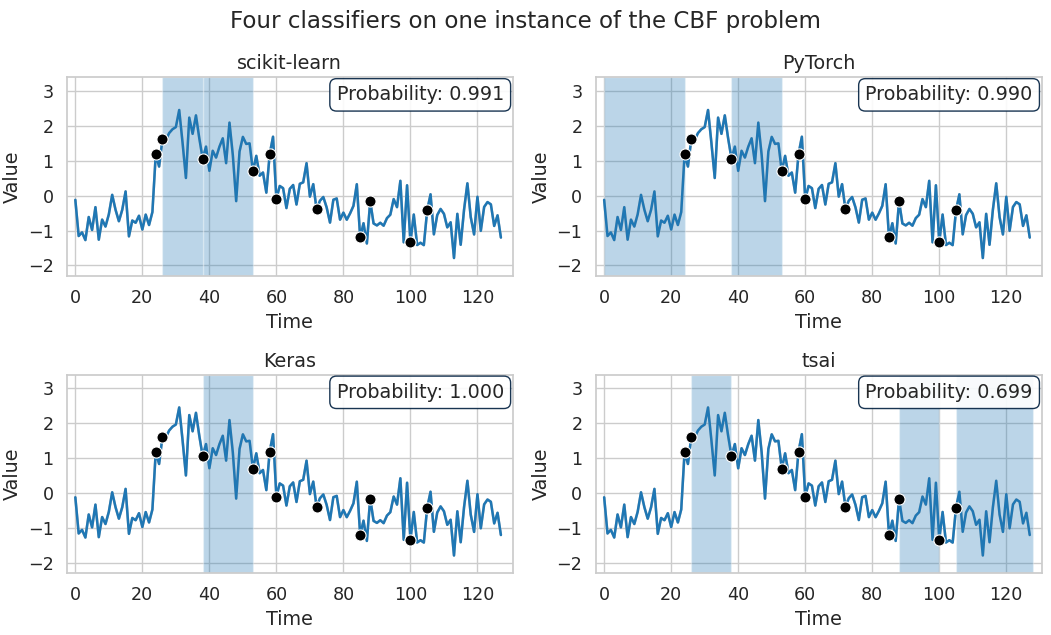

In [29]:
by_framework = study.compare_explainers(
    instance,
    {
        "scikit-learn": sklearn_explainer,
        "PyTorch": torch_explainer,
        "Keras": keras_explainer,
        "tsai": tsai_explainer,
    },
    segmentation=segmentation,
)

study.plot_explanation_grid(
    by_framework, ncols=2, panel_size=(5.2, 3.2),
    title="Four classifiers on one instance of the CBF problem",
)
plt.show()

In [30]:
study.summarize(by_framework).round(4)

,run,predicted,confidence,ds,sparsity_rate,n_segments,model_queries,runtime,top_3
0,scikit-learn,3,0.9908,0.8197,0.1667,12,300,0.2587,"s3, s2, s9"
1,PyTorch,3,0.9897,0.5767,0.1667,12,302,0.8750,"s3, s0, s2"
2,Keras,3,0.9995,0.5915,0.0833,12,194,1.5742,"s3, s0, s11"
3,tsai,3,0.6992,0.2492,0.2500,12,262,9.2000,"s11, s2, s9"


### Comparing against rankings obtained elsewhere

`compare_rankings` evaluates rankings produced by other methods by establishing the degradation score as a common basis for comparison. Feature occlusion orders the segments by the degradation each of them causes in isolation, a random ordering provides a lower reference, and the reversed SOFI ranking provides the worst case.

The comparison also carries a theoretical reading. Under the modularity assumption of Theorem 3, the effect of marginalizing a segment does not depend on what was marginalized before, the contributions simply add up, and the optimal ranking is exactly the one obtained by sorting those individual contributions, which is what feature occlusion produces. So when the searched ranking coincides with the occlusion ranking, the instance behaves as the modular case predicts. The converse does not follow, since the two orderings may agree by coincidence, and `modularity_gap` settles the question directly by measuring how far the observed curve departs from the additive prediction.

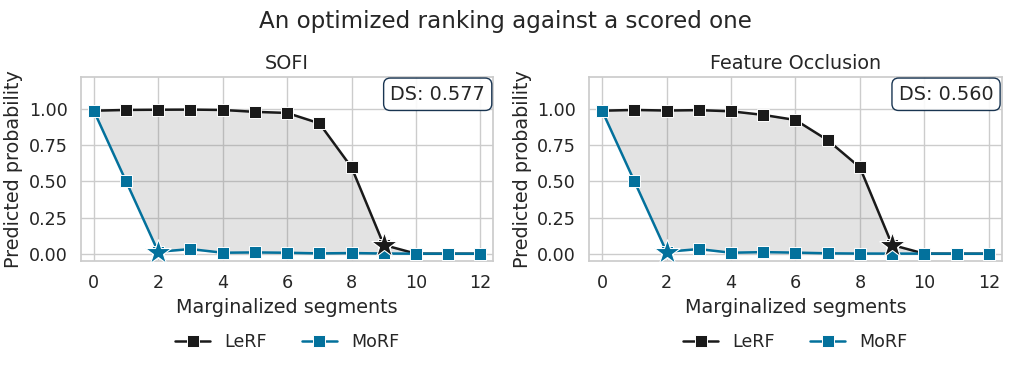

SOFI      ranking: s3, s0, s2, s11, s9, s7, s6, s5, s4, s8, s1, s10
occlusion ranking: s3, s0, s2, s11, s5, s6, s4, s7, s8, s1, s9, s10

identical rankings: False
degradation scores: 0.5767 for SOFI against 0.5597
modularity gap: 0.29


In [31]:
sofi = explainer.explain(instance, segmentation=segmentation)
occlusion_ranking = sofits.ranking_from_scores(
    sofits.feature_occlusion(explainer, instance, segmentation)
)
occlusion = explainer.score_ranking(instance, occlusion_ranking, segmentation=segmentation)

study.plot_degradation_grid(
    {"SOFI": sofi, "Feature Occlusion": occlusion}, ncols=2,
    title="An optimized ranking against a scored one",
)
plt.show()

print("SOFI      ranking:", ", ".join(sofi.ranking))
print("occlusion ranking:", ", ".join(occlusion.ranking))
print()
print("identical rankings:", sofi.ranking == occlusion.ranking)
print("degradation scores:", round(sofi.ds, 4), "for SOFI against", round(occlusion.ds, 4))
print("modularity gap:", round(sofi.modularity_gap, 4))

In [32]:
study.compare_rankings(
    instance,
    {
        "SOFI": sofi.order,
        "Feature Occlusion": occlusion_ranking,
        "Random": sofits.random_ranking(segmentation.n_segments, RANDOM_STATE),
        "Reversed SOFI": sofi.order[::-1],
    },
    segmentation=segmentation,
).round(4)

,method,ds,auc_morf,auc_lerf,sparsity_rate,top_segment
0,SOFI,0.5767,0.0896,0.6664,0.1667,s3
1,Feature Occlusion,0.5597,0.0896,0.6493,0.1667,s3
2,Random,0.2765,0.1792,0.4557,0.1667,s0
3,Reversed SOFI,-0.5767,0.6664,0.0896,0.7500,s10


The rankings produced by SOFI and Feature Occlusion aggree on their leading segments and diverge afterwards, while their degradation scores remain close. Distinct orderings therefore account for the decision almost equally well, which is the multimodality of the explanation space discussed in the paper. A single ranking should accordingly be read as one adequate explanation among several rather than as the only one.

### Running over a batch

Change point detection applies to one instance at a time, so the segments of two instances do not correspond and their rankings cannot be pooled. A partition shared by construction removes the obstacle, which is the case of uniform binning and of expert breakpoints. The batch below is therefore explained on a uniform partition, and the mean rank of every segment summarizes what the model relies on across instances rather than on one of them.

`robustness` closes the study illustrates in this notebook by measuring how far the ranking of an instance agrees with the ranking of its nearest neighbor, through rank biased overlap. That measure rests on the (very naive) assumption that locally similar series deserve similar explanations, which is common yet not correlated with faithfulness or sparsity, so the number is informative alongside the others and misleading on its own.

In [33]:
batch = reliable[:12]
shared = sofits.uniform_segmentation(N_SEGMENTS, cbf.n_timestamps, n_channels=cbf.n_channels)

batch_runs = study.explain_batch(batch, segmentation=shared)
study.aggregate(batch_runs).round(4)

,segment,mean_rank,std_rank,top3_frequency
0,s2,5.2500,4.0234,0.4167
1,s4,5.5000,3.5000,0.4167
2,s1,5.6667,3.1710,0.3333
3,s5,5.7500,2.5536,0.1667
4,s9,6.0833,4.2320,0.3333
5,s3,6.1667,2.8235,0.2500
6,s6,6.2500,3.3696,0.2500
7,s8,6.2500,3.3448,0.3333
8,s11,6.5833,3.2521,0.2500
9,s10,7.0833,2.5967,0.1667


In [34]:
print("robustness over the batch:", round(study.robustness(batch_runs, batch), 4))

robustness over the batch: 0.5383
